<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_1/MINE_4210_ADL_202620_L1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Laboratorio 1: Introducción a Redes Neuronales**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Comprensión de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación de los datos](#scrollTo=OAgSkgZqwZBI&line=1&uniqifier=1)<br>
[3. Modelamiento](#scrollTo=ExUWSrFJZnLB&line=1&uniqifier=1)<br>
[4. Evaluación](#scrollTo=fYtfPNjMwlM5&line=1&uniqifier=1)<br>
[5. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- En este problema queremos predecir el consumo energético de los electrodomésticos (en vatios-hora) utilizando 28 variables explicativas de una vivienda de bajo consumo.

**Objetivos**
1. Preparar las características de entrada y la variable objetivo para el modelado.
2. Construir nuestro primer modelo basado en redes neuronales con arquitectura MLP, validar resultados y observar sus limitaciones.


**Datos**

Los datos los puedes consultar [aquí](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction).

In [ ]:
# Librerias que necesitamos para este lab
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

### **1. Comprensión de los datos**

El conjunto de datos "Appliances Energy Prediction" consta de 19735 mediciones de series temporales registradas cada 10 minutos durante aproximadamente 4.5 meses en una vivienda de bajo consumo energético situada en Bélgica. Diseñado para la regresión multivariante de series temporales, donde su objetivo principal es predecir el consumo energético de los electrodomésticos (en vatios-hora) utilizando 28 características.

Dentro de las variables predictoras encontramos métricas de temperatura interior, humedad relativa en nueve habitaciones distintas y datos metereológicos de la localidad común.

**Diccionario de datos:**

| Atributo &nbsp; &nbsp;| Descripción |
|-|-|
| date | Timestamp logged in 10-minute intervals |
| Appliances | Total energy consumption by appliances |
| lights | Energy consumption of light fixtures in the house |
| T1 | Temperature in kitchen area |
| RH_1 | Relative humidity in kitchen area |
| T2 | Temperature in living room area |
| RH_2 | Relative humidity in living room area |
| T3 | Temperature in laundry room area |
| RH_3 | Relative humidity in laundry room area |
| T4 | Temperature in office room |
| RH_4 | Relative humidity in office room |
| T5 | Temperature in bathroom |
| RH_5 | Relative humidity in bathroom |
| T6 | Temperature outside the building (north side) |
| RH_6 | Relative humidity outside the building (north side) |
| T7 | Temperature in ironing room |
| RH_7 | Relative humidity in ironing room |
| T8 | Temperature in teenager room 2 |
| RH_8 | Relative humidity in teenager room 2 |
| T9 | Temperature in parents room |
| T_out | Outdoor temperature from weather station |
| Press_mm_hg | Atmospheric pressure from weather station |
| RH_out | Outdoor humidity from weather station |
| Windspeed | Wind speed from weather station |
| Visibility | Visibility distance from weather station |
| Tdewpoint | Dew point temperature from weather station |
| rv1 | Random variable 1 (used for feature selection/filtering) |
| rv2 | Random variable 2 (used for feature selection/filtering) |

In [ ]:
# Cargamos los datos directamente del repositorio
url = 'https://raw.githubusercontent.com/nicolastibata/MINE_4210_ADL_202620/refs/heads/main/labs/Laboratorio_1/energydata_complete.csv'
data = pd.read_csv(url)
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


**Pasos de procesamiento:**
- No encontramos nulos en el conjunto de los datos, no necesitamos imputadores.
- Las variables aleatorias no las tendremos en cuenta ya que se usaron para un proceso de regresión anterior. Así como `date`, ya que nuestra tarea no es basada en series temporales, para eso más adelante usaremos un modelo secuencia como un LSTM.
- Las variables metereológicas contienen rangos dispersos en comparación con las variables de vivienda, usaremos un normalizador.

### **2. Preparación de los datos**

In [ ]:
# Iniciamos con la creación de nuestro pipeline
dropper = ColumnTransformer(
    transformers=[('drop_columns', 'drop', ['date', 'rv1', 'rv2'])],
    remainder='passthrough'
)

preprocessing_pipeline = Pipeline([
    ('drop_step', dropper), # 1. Eliminar variables aleatorias
    ('scaler_step', StandardScaler()) # 2. Escalar variables numericas
])

preprocessing_pipeline

Pipeline(steps=[('drop_step',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('drop_columns', 'drop',
                                                  ['date', 'rv1', 'rv2'])])),
                ('scaler_step', StandardScaler())])

### **3. Modelamiento**

Vamos a utilizar la arquitectura MLP de una sola capa oculta, la cual se ve de la siguiente manera para este caso:

![Multilayer Perceptron](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/MLPLab1.drawio.png?raw=true)

Para ello, lo primero que definiremos será nuestro modelo.


---

La libreria Keras nos permite crear modelos secuenciales mediante la clase `Sequential`, primero definimos el modelo y le asignamos un nombre, seguido se usa el método `add` para ir adicionando las capas que vamos requiriendo.

> La primera capa, que corresponde a la capa de entrada (**Input Layer**), se debe especificar con el número de neuronas que corresponde al número de características que vamos a tener en nuestro modelo, en este caso nuestros datos en X contienen 25 columnas o variables explicativas, por ende se requieren 25 neuronas. Una forma general de definirlo es usando el método shape: X.shape[1]

> Seguido a la capa de entrada agregamos una capa de tipo **Dense**, que será nuestra capa oculta, la cual inicialmente asignaremos 3 neuronas y utilizará la función de activación RELU.

> Finalmente, se adiciona la capa de salida (también de tipo Dense pero al ser una tarea de regresión definimos una sola neurona y puede ser sin función de activación o de activación lineal) que nos dará el resultado de las predicciones de nuestro modelo.

In [ ]:
# Iniciamos con la separación de nuestro dataset a entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(data.drop('Appliances', axis=1), data['Appliances'], test_size=0.2, random_state=71)
print(X_train.shape) # 28 variables predictoras
print(y_train.shape) # 1 variable target
print(X_test.shape)
print(y_test.shape)

(15788, 28)
(15788,)
(3947, 28)
(3947,)


In [ ]:
# Luego aplicamos el pipeline construido en la sección anterior
X_train_scaled = preprocessing_pipeline.fit_transform(X_train) # OJO aplicamos fit-transform al set de entrenamiento
print(X_train_scaled) # Debemos procesar los datos para que sean un dataframe y no listas de arreglos

[[-0.47593419  0.05781166 -0.14682586 ... -0.42796093 -1.04540754
   0.68816464]
 [-0.47593419  1.92601587  1.75635285 ... -0.49610228  0.1421524
   2.3348026 ]
 [ 3.34024104  0.72206205  1.28243878 ...  1.34371435 -0.14059996
   1.61091828]
 ...
 [-0.47593419 -0.30960184 -0.52461978 ... -0.01911278 -0.79093041
  -0.50505128]
 [ 2.06818263  0.12008513  0.07634003 ...  1.47999707  0.1421524
   0.6125943 ]
 [ 0.79612422  0.25085943  0.51180604 ... -0.29167821 -0.6354166
   1.0501068 ]]


In [ ]:
feature_names = preprocessing_pipeline.get_feature_names_out()
# Reconstruimos nuestro dataframe de entrenamiento
X_train_processed = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_processed.head()

,remainder__lights,remainder__T1,remainder__RH_1,remainder__T2,remainder__RH_2,remainder__T3,remainder__RH_3,remainder__T4,remainder__RH_4,remainder__T5,...,remainder__T8,remainder__RH_8,remainder__T9,remainder__RH_9,remainder__T_out,remainder__Press_mm_hg,remainder__RH_out,remainder__Windspeed,remainder__Visibility,remainder__Tdewpoint
16218,-0.475934,0.057812,-0.146826,0.276600,0.160009,0.369490,-0.469833,0.451664,-0.173884,0.118273,...,0.234710,0.085812,0.295893,0.028931,0.155604,0.895469,0.690658,-0.427961,-1.045408,0.688165
17335,-0.475934,1.926016,1.756353,1.158623,2.175193,2.181084,1.304489,2.022060,1.462550,2.378568,...,2.074673,1.884498,2.249850,1.334188,1.343035,-0.883885,0.959292,-0.496102,0.142152,2.334803
2900,3.340241,0.722062,1.282439,0.843832,0.839118,-0.196166,2.235030,-0.477853,2.604909,-0.158927,...,-0.122493,1.886839,-1.277852,2.158287,0.796440,-0.281780,0.892133,1.343714,-0.140600,1.610918
5551,-0.475934,-1.056884,-1.024444,-1.011459,-0.750392,-1.052659,-0.323189,-1.402478,-0.585870,-1.409636,...,-1.150373,0.122207,-0.943927,-0.268763,-1.427638,0.527017,1.295084,-0.836809,-1.186784,-0.962451
8793,0.796124,-0.745516,-1.851913,-0.616069,-1.899466,-1.138094,-1.797312,-0.282165,-1.414444,-0.637564,...,1.512462,-1.747992,-0.267812,-0.570572,0.070787,1.542507,-1.156199,-0.427961,2.177969,-0.660169


In [ ]:
model = Sequential(name="MLP_Regression")

model.add(Input(shape=(X_train_processed.shape[1],), name='Input_Layer'))
model.add(Dense(32,activation='relu',name='Hidden_Layer'))
model.add(Dense(1,activation='linear',name='Output_Layer'))

El método `compile` permite configurar nuestro modelo para el entrenamiento. Este método acepta varios argumentos, como el *optimizer*, el *loss* y las *metrics*, que se utilizan para optimizar los pesos del modelo durante el entrenamiento.

In [ ]:
model.compile(loss='mse', optimizer='adam', metrics=['mae', 'mse'])

model.summary()

Model: "MLP_Regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
history = model.fit(
    X_train_processed,
    y_train,
    batch_size=10,
    epochs=50
)

Epoch 1/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 13569.5586 - mae: 66.8848 - mse: 13569.5586
Epoch 2/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 10210.7412 - mae: 56.9912 - mse: 10210.7412
Epoch 3/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9588.7246 - mae: 54.8612 - mse: 9588.7246
Epoch 4/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9277.1953 - mae: 54.0070 - mse: 9277.1953
Epoch 5/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9070.4492 - mae: 53.2849 - mse: 9070.4492
Epoch 6/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8936.2617 - mae: 53.0654 - mse: 8936.2617
Epoch 7/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8835.2119 - mae: 52.6685 - mse: 8835.2119
Epoch 8/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8758.9219 - mae: 52.5723 - mse: 8758.9219
Epoch 9/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8692.7598 - mae: 52.1954 - mse: 8692.7598
Epoch 10/50
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - los

**Veamos los resultados de nuestro modelo con los datos de entrenamiento**

In [ ]:
y_pred = model.predict(X_train_processed).flatten()
# Calculemos las métricas
mae = mean_absolute_error(y_train, y_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
r2 = r2_score(y_train, y_pred)

print("\n--- Métricas de Regresión para Train ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} Wh")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} Wh")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")

494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Métricas de Regresión para Train ---
MAE (Error Absoluto Medio): 49.91 Wh
RMSE (Raíz del Error Cuadrático Medio): 88.86 Wh
R² Score (Coeficiente de Determinación): 0.2540


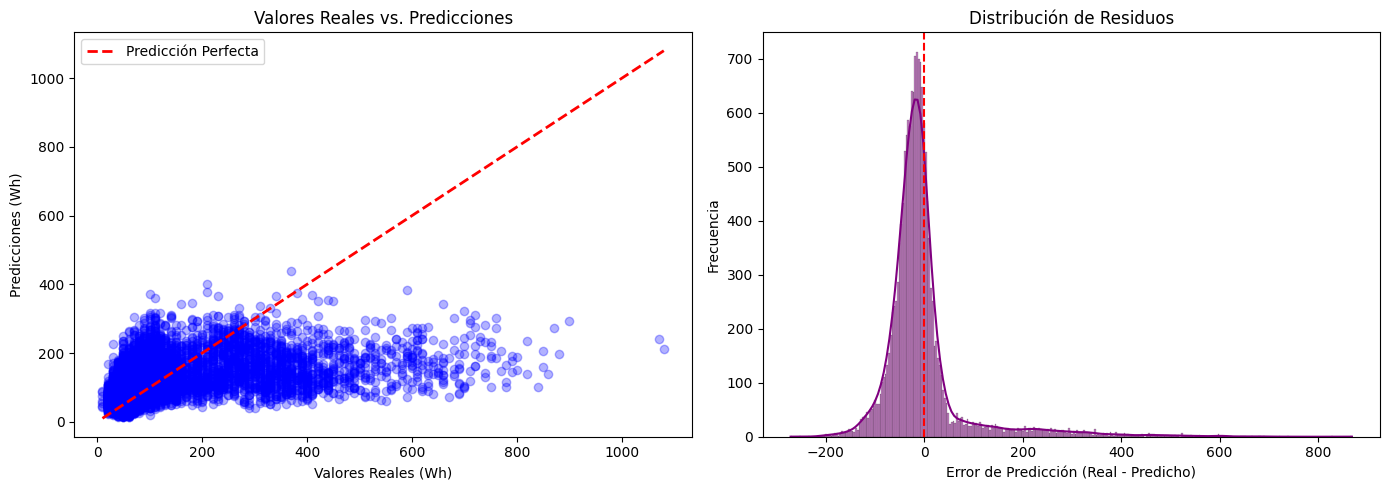

In [ ]:
plt.figure(figsize=(14, 5))
# Grafiquemos los valores reales vs los predichos
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred, alpha=0.3, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.xlabel('Valores Reales (Wh)')
plt.ylabel('Predicciones (Wh)')
plt.title('Valores Reales vs. Predicciones')
plt.legend()

# Grafiquemos la distribución del error
plt.subplot(1, 2, 2)
residuos = y_train - y_pred
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Error de Predicción (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')

plt.tight_layout()
plt.show()

### **4. Evaluación**

In [ ]:
# Antes de evaluar en test, debemos aplicar el mismo pipeline para este conjunto de datos
X_test_scaled = preprocessing_pipeline.transform(X_test) # OJO acá solo aplicamos el transform al set de prueba

# Transformamos a dataframe
feature_names = preprocessing_pipeline.get_feature_names_out()
X_test_processed = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)
X_test_processed.head()

,remainder__lights,remainder__T1,remainder__RH_1,remainder__T2,remainder__RH_2,remainder__T3,remainder__RH_3,remainder__T4,remainder__RH_4,remainder__T5,...,remainder__T8,remainder__RH_8,remainder__T9,remainder__RH_9,remainder__T_out,remainder__Press_mm_hg,remainder__RH_out,remainder__Windspeed,remainder__Visibility,remainder__Tdewpoint
5273,-0.475934,-1.056884,-1.375492,-1.300398,-1.111272,-0.981106,-0.499776,-1.060025,-1.184285,-0.711524,...,-0.639272,-0.877223,-0.745556,-0.683408,-2.234966,1.086435,0.713044,-1.245657,2.107281,-2.267033
17938,-0.475934,1.054187,-1.149819,-0.027546,-0.430522,0.999935,-0.722430,1.337152,-1.115237,1.994336,...,1.183654,-1.276133,1.771279,-0.337099,-0.535494,0.756177,0.489183,-0.700526,0.142152,-0.298227
16811,-0.475934,1.496329,-0.936683,3.763634,-2.877778,1.353781,-0.701956,1.386074,-0.593542,1.236695,...,0.963880,-0.419889,1.364122,-0.061612,2.605859,-0.398606,-2.600106,-0.087254,0.142152,0.855215
2402,-0.475934,-1.866439,1.483037,-1.122472,1.422267,-1.337445,1.639238,-1.549244,1.761758,-1.282460,...,-2.388373,1.229279,-1.390262,1.350033,-0.654865,1.138109,0.936906,-0.836809,-0.847481,-0.186860
4010,-0.475934,-0.371875,1.071810,-0.027546,0.561077,0.357031,1.025020,0.065181,0.910167,-0.425905,...,-0.096938,0.878524,-0.249628,0.413738,0.237279,-2.164480,-0.719669,3.660520,0.142152,-0.131177


**Ahora evaluemos el modelo con los datos de test**

In [ ]:
y_pred = model.predict(X_test_processed).flatten()
# Calculemos las métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas de Regresión para Test ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} Wh")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} Wh")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Métricas de Regresión para Test ---
MAE (Error Absoluto Medio): 50.29 Wh
RMSE (Raíz del Error Cuadrático Medio): 89.24 Wh
R² Score (Coeficiente de Determinación): 0.2200


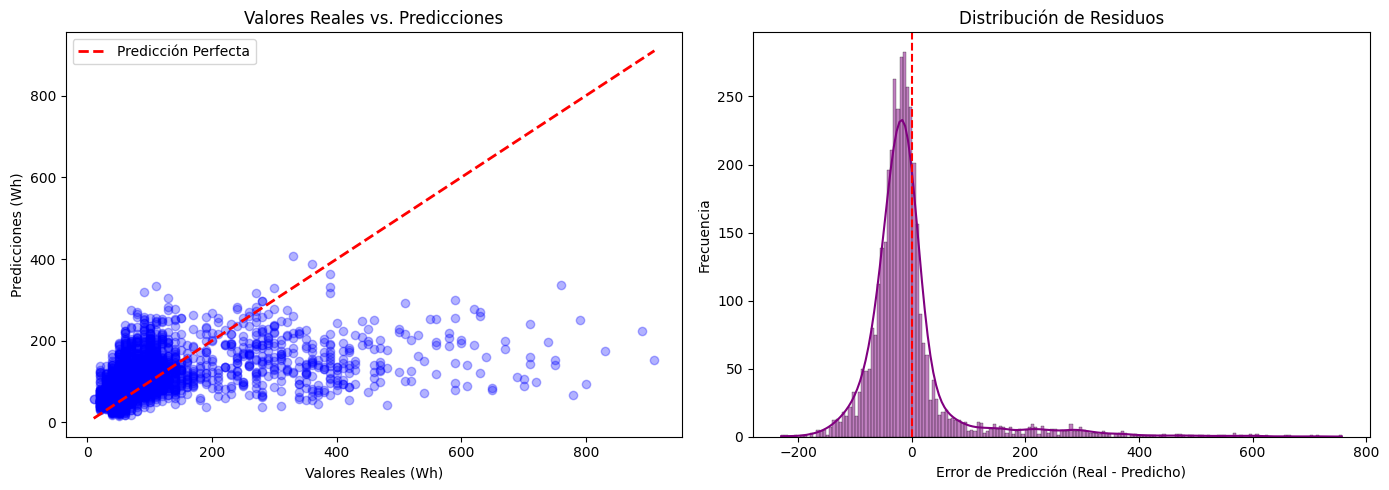

In [ ]:
plt.figure(figsize=(14, 5))
# Grafiquemos los valores reales vs los predichos
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.xlabel('Valores Reales (Wh)')
plt.ylabel('Predicciones (Wh)')
plt.title('Valores Reales vs. Predicciones')
plt.legend()

# Grafiquemos la distribución del error
plt.subplot(1, 2, 2)
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Error de Predicción (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')

plt.tight_layout()
plt.show()

- Aumentar la cantidad de neuronas en una sola capa oculta no permite predecir de manera correcta cuando el consumo energético es alto (ya que el consumo medio/bajo si logra predecir relativamente bien). Cuáles son las oportunidades de mejora? Mayor cantidad de capas ocultas, búsqueda de hiperparámetros, diferentes funciones de activación.

### **5. Preguntas**

1. Al entrenar nuestro modelo vemos que el modelo tiene 832 parámetros en el primer paso de nuestra red. ¿Cómo se calcula esa cantidad de parámetros?

2. ¿De qué depende la cantidad de neuronas en la capa de salida?

3. En este caso, ¿cómo intrepretamos RMSE y MSE? ¿Cuáles son sus diferencias?